In [29]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.stats import gaussian_kde
from models import CondSM
from utils import f_sm, sample_X, mse_loss_normalized, normalize_over_range
import pandas as pd

latex_txt_width = 404.02908 # in pt
in_per_pt = 1 / 72.27
width_in_pt = latex_txt_width * in_per_pt
height_in_pt = 0.618 * width_in_pt

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "legend.fontsize": 12,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

import matplotlib.pyplot as plt
import numpy as np

def make_gate_template(figsize=(6,4)):
    fig = plt.figure(figsize=figsize)

    # Fixed axes rectangles in figure coordinates: [left, bottom, width, height]
    ax0 = fig.add_axes([0.15, 0.72, 0.80, 0.20])  # V0
    ax1 = fig.add_axes([0.15, 0.47, 0.80, 0.20])  # V1
    ax2 = fig.add_axes([0.15, 0.15, 0.80, 0.28])  # Iout (with xticks/labels)

    axes = [ax0, ax1, ax2]

    def style_axis(ax, label):
        ax.set_ylabel(label, rotation=90.0)
        ax.grid(alpha=0.3)
        ax.set_facecolor("whitesmoke")
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    style_axis(ax0, "$V_0$")
    style_axis(ax1, "$V_1$")
    style_axis(ax2, "$I_{\\mathrm{out}} \\quad [nA]$")

    return fig, axes

def clear_axes_keep_layout(axes):
    # clears plotted data but keeps axes objects/positions
    for ax in axes:
        ax.cla()

def restyle_after_clear(axes):
    # re-apply your styling after cla()
    labels = ["$V_0$", "$V_1$", "$I_{\\mathrm{out}} \\quad [nA]$"]
    for ax, lab in zip(axes, labels):
        ax.set_ylabel(lab, rotation=90.0)
        ax.grid(alpha=0.3)
        ax.set_facecolor("whitesmoke")
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

def draw_gate_on_axes(axes, gate_inputs, currents, sem=None, label=None, ls="-", lw=2, show_legend=False):
    in_0 = [gi[0] for gi in gate_inputs]
    in_1 = [gi[1] for gi in gate_inputs]
    y = np.asarray(currents, float).reshape(-1)

    t = np.arange(len(gate_inputs) + 1)

    # inputs
    axes[0].step(t, np.r_[in_0, in_0[-1]], where="post", lw=2)
    axes[1].step(t, np.r_[in_1, in_1[-1]], where="post", lw=2)

    # output
    axes[2].step(t, np.r_[y, y[-1]], where="post", lw=lw, ls=ls, label=label)

    if sem is not None:
        sem = np.asarray(sem, float).reshape(-1)
        lo = np.r_[y - sem, (y - sem)[-1]]
        hi = np.r_[y + sem, (y + sem)[-1]]
        axes[2].fill_between(t, lo, hi, step="post", alpha=0.25)

    centers = np.arange(len(gate_inputs)) + 0.5
    state_labels = ["00", "01", "10", "11"][:len(gate_inputs)]
    axes[2].set_xticks(centers)
    axes[2].set_xticklabels(state_labels)
    axes[2].set_xlabel("Input $V_0, V_1 \\quad [V]$")

    if show_legend:
        axes[2].legend(frameon=False, loc="best")

# -----------------------------
# Utilities
# -----------------------------
def _as_numpy_2d(X) -> np.ndarray:
    X = np.asarray(X)
    if X.ndim != 2:
        raise ValueError(f"X must be 2D. Got shape {X.shape}")
    if X.shape[1] != 6:
        raise ValueError(f"Expected X to have 6 columns, got {X.shape[1]}")
    return X.astype(np.float64, copy=False)

def _as_numpy_1d(y) -> np.ndarray:
    y = np.asarray(y).reshape(-1)
    return y.astype(np.float64, copy=False)

def _rng(seed: int) -> np.random.Generator:
    return np.random.default_rng(seed)

def subsample_indices(n: int, max_n: int, rng: np.random.Generator) -> np.ndarray:
    if max_n is None or max_n >= n:
        return np.arange(n, dtype=np.int64)
    return rng.choice(n, size=max_n, replace=False).astype(np.int64)

def maybe_invert_for_minimize(y: np.ndarray, minimize: bool) -> np.ndarray:
    # For tail classification: "good" means lower if minimize, higher if maximize.
    return y if minimize else -y

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
print('Libraries loaded')

e_0 = 1.60217663e-19
time_scale = 1e21
out_scale = e_0 * time_scale

cuda
Libraries loaded


In [67]:
data_type = 'data_vMB_ring_1e7'
state_dict = torch.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/final_datasets/{data_type}/sm_{data_type}_baseline_0_epochs=1000_dp=0.1_bn=True_hd=90_ls=5_noise=True.pth', weights_only=False, map_location='cuda')

model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])

input_index = 3
print("Model loaded")

Model loaded


In [68]:
def mse_loss_normalized(x, y):

    x = x.float()
    y = y.float()
    x_norm = (x - x.mean()) / (x.std(unbiased=False) + 1e-8)
    y_norm = (y - y.mean()) / (y.std(unbiased=False) + 1e-8)
    
    mse = torch.mean((y_norm - x_norm)**2).item()

    return mse

func_type = 'Parabola'

if func_type == 'ReLU':
    def target_function(x):
        m = nn.ReLU()
        return m(x)
elif func_type == 'Sigmoid':
    def target_function(x):
        m = nn.Sigmoid()
        return m(4*x)
elif func_type == 'Parabola':
    def target_function(x):
        return x**2
elif func_type == 'Cubic':
    def target_function(x):
        return x**3
elif func_type == 'Sine':
    def target_function(x):
        return torch.sin(3*x)
elif func_type == 'Cosine':
    def target_function(x):
        return torch.cos(3*x)

def normalize_over_range(x):
    
    z = (x - x.mean()) / (x.std() + 1e-8) 
    
    return z

num_curve_points = 50
num_voltages = 7
control_indices = [c_index for c_index in range(num_voltages) if c_index != input_index]
print(control_indices)
v_min = -1.5
v_max = 1.5
curve_range = torch.linspace(v_min, v_max, num_curve_points)
target_input_range = torch.linspace(v_min, v_max, num_curve_points).unsqueeze(1)
target = target_function(target_input_range)

[0, 1, 2, 4, 5, 6]


In [69]:
import torch

seed = 42
torch.manual_seed(seed)

num_samples = 1_000_000
c_v_min, c_v_max = -1.5, 1.5

thetas = torch.rand(size=(num_samples, 6), device=device, dtype=torch.float32) * (c_v_max - c_v_min) + c_v_min
max_l2 = 2.0
l2 = thetas.norm(dim=1)                       # ||theta||_2 for each sample  -> shape [N]
scale = torch.clamp(max_l2 / (l2 + 1e-12), max=1.0)
thetas = thetas * scale.unsqueeze(1)

model = model.to(device).eval()

# --- move constants to device once ---
control_indices_t = torch.tensor(control_indices, device=device, dtype=torch.long)
curve_range_t = torch.as_tensor(curve_range, device=device, dtype=torch.float32)  # [num_curve_points]
target_t = target.to(device) if isinstance(target, torch.Tensor) else torch.as_tensor(target, device=device)

# Prebuild a "base" input for a single sample: [P, V]
base = torch.zeros(num_curve_points, num_voltages, device=device, dtype=torch.float32)
base[:, input_index] = curve_range_t

batch_size = 4*4096  # try 256/512/1024 depending on VRAM
scores = torch.empty(num_samples, device=device, dtype=torch.float32)

mse = mse_loss_normalized  # keep your function

with torch.inference_mode():
    for start in range(0, num_samples, batch_size):
        end = min(start + batch_size, num_samples)
        B = end - start

        # Build batch input: [B, P, V] by expanding base
        x = base.unsqueeze(0).expand(B, -1, -1).clone()

        # Put controls in: theta[start:end] is [B, d]
        # Expand to [B, P, d], then assign into voltage columns
        controls = thetas[start:end].unsqueeze(1).expand(-1, num_curve_points, -1)
        x.index_copy_(2, control_indices_t, controls)  # write d columns at once
        #print(x)

        # If model expects 2D points, flatten to [B*P, V]
        x2d = x.reshape(-1, num_voltages)

        y = model(x2d)  # whatever output shape your model produces per point

        # You likely need to reshape y back per-sample before scoring
        # Example if y is [B*P, out_dim] -> [B, P, out_dim]
        y = y.reshape(B, num_curve_points, *y.shape[1:])

        # Compute per-sample fitness
        # If your mse_loss_normalized returns a scalar for one sample,
        # you can vectorize it; otherwise loop *inside the batch* (much cheaper).
        # Here’s a safe fallback loop inside batch:
        for i in range(B):
            #print(y[i].shape)
            scores[start + i] = mse(y[i].detach().cpu(), target)  # adjust if mse expects tensors on CPU/GPU

# move back to CPU for Python ops
scores_cpu = scores.detach().cpu().tolist()
min_score = min(scores_cpu)
max_score = max(scores_cpu)
max_index = scores_cpu.index(max_score)
min_index = scores_cpu.index(min_score)

print(max_index)
print(min_score)
print(max_score)
print(thetas[min_index].tolist())
print("Done")

513946
0.012617026455700397
3.9913580417633057
[-0.31849148869514465, 0.9154839515686035, -0.11052609980106354, 1.048065185546875, -0.313292533159256, -1.3607510328292847]
Done


"fig.savefig(f'random_ecdf_data_type={data_type}_func={func_type}_cmin={c_v_min}_cmax={c_v_max}_seed={seed}_maxl2={max_l2}_input_idx={input_index}.pdf')\nnp.savetxt(\n    f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/1d_funcs_random/'\n    f'random_data_type={data_type}_func={func_type}_cmin={c_v_min}_cmax={c_v_max}_seed={seed}_maxl2={max_l2}_input_idx={input_index}.txt',\n    thetas[min_index].tolist()\n)\nnp.savetxt(\n    f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/1d_funcs_random/'\n    f'scores_random_data_type={data_type}_func={func_type}_cmin={c_v_min}_cmax={c_v_max}_seed={seed}_maxl2={max_l2}_input_idx={input_index}.txt',\n    scores.detach().cpu().numpy().tolist()\n)"

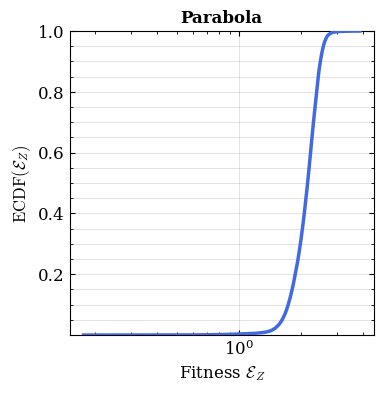

In [9]:
scores = scores.cpu()
s = np.asarray(scores, float)
s = s[np.isfinite(s)]
s_sorted = np.sort(s)
n = len(s_sorted)

ecdf = np.arange(1, n+1) / n
ccdf = 1 - ecdf

fig, ax = plt.subplots(figsize=(4,4))
ax.set_position([0.18, 0.12, 0.76, 0.83])
ax.minorticks_on()
ax.tick_params(top=True, right=True, which='both')
ax.tick_params(which='both', direction='in')

#ax.plot(s_sorted, ccdf, lw=2.5, zorder=6, c='royalblue')
#ax.set_yscale('log')
#ax.set_ylabel(r'$1-\mathrm{ECDF}(S_0)$')
ax.set_ylabel(r'$\mathrm{ECDF}(\mathcal{E}_Z)$')
ax.set_ylim(1/n, 1)  # avoid 0 on log scale
ax.set_xscale('log')
#ax.set_xscale('log')
ax.plot(s_sorted, ecdf, lw=2.5, zorder=6, c='royalblue')

ax.grid(lw=0.5, alpha=0.5, which='major')
ax.grid(lw=0.5, alpha=0.5, which='minor', axis='y')

ax.set_xlabel(r'Fitness $\mathcal{E}_Z$')
ax.set_box_aspect(1)
ax.set_title(f'{func_type}', fontdict={'weight': 'bold'})

"""fig.savefig(f'random_ecdf_data_type={data_type}_func={func_type}_cmin={c_v_min}_cmax={c_v_max}_seed={seed}_maxl2={max_l2}_input_idx={input_index}.pdf')
np.savetxt(
    f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/1d_funcs_random/'
    f'random_data_type={data_type}_func={func_type}_cmin={c_v_min}_cmax={c_v_max}_seed={seed}_maxl2={max_l2}_input_idx={input_index}.txt',
    thetas[min_index].tolist()
)
np.savetxt(
    f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/1d_funcs_random/'
    f'scores_random_data_type={data_type}_func={func_type}_cmin={c_v_min}_cmax={c_v_max}_seed={seed}_maxl2={max_l2}_input_idx={input_index}.txt',
    scores.detach().cpu().numpy().tolist()
)"""

## fitness parameter plots

In [103]:
""" pariwise heatmap 2d """
# -----------------------------
# 3.C Pairwise response surfaces (2D heatmaps)
# -----------------------------
def pairwise_heatmap_2d(
    X: np.ndarray,
    y: np.ndarray,
    i: int,
    j: int,
    bins: int = 20,
    quantile: float = 0.1,              # low quantile per cell (use 0.01 = 1%)
    min_cell_count: int = 200,           # mask cells with too few samples
    quantile_subsample: int = 2_000_000, # quantiles computed on a big subsample
    seed: int = 0,
):
    """
    Returns:
      - mean_grid: (bins, bins) mean score per cell (ALL data)
      - q_grid:    (bins, bins) quantile score per cell (approx from subsample)
      - count_grid:(bins, bins) sample count per cell (ALL data)
      - edges_i, edges_j
    """
    rng = _rng(seed)
    X = _as_numpy_2d(X)
    y = _as_numpy_1d(y)
    n = len(y)

    xi, xj = X[:, i], X[:, j]
    ei = np.linspace(float(np.min(xi)), float(np.max(xi)), bins + 1)
    ej = np.linspace(float(np.min(xj)), float(np.max(xj)), bins + 1)

    bi = np.clip(np.digitize(xi, ei) - 1, 0, bins - 1).astype(np.int32)
    bj = np.clip(np.digitize(xj, ej) - 1, 0, bins - 1).astype(np.int32)
    flat = bi * bins + bj

    counts = np.bincount(flat, minlength=bins * bins).astype(np.int64)
    sums = np.bincount(flat, weights=y, minlength=bins * bins).astype(np.float64)
    mean = np.divide(sums, counts, out=np.full(bins * bins, np.nan), where=counts > 0)

    mean_grid = mean.reshape(bins, bins)
    count_grid = counts.reshape(bins, bins)

    # quantile grid approx via subsample + pandas groupby (fast enough at ~1-2M)
    idx = subsample_indices(n, quantile_subsample, rng)
    Xs, ys = X[idx], y[idx]
    bis = np.clip(np.digitize(Xs[:, i], ei) - 1, 0, bins - 1)
    bjs = np.clip(np.digitize(Xs[:, j], ej) - 1, 0, bins - 1)
    flats = bis * bins + bjs
    df = pd.DataFrame({"cell": flats, "y": ys})
    q = df.groupby("cell")["y"].quantile(quantile)
    q_vec = np.full(bins * bins, np.nan, dtype=float)
    q_vec[q.index.to_numpy()] = q.to_numpy()
    q_grid = q_vec.reshape(bins, bins)

    # mask low-count cells (using ALL-data counts)
    mask = count_grid < min_cell_count
    mean_grid = mean_grid.copy()
    q_grid = q_grid.copy()
    mean_grid[mask] = np.nan
    q_grid[mask] = np.nan

    return mean_grid, q_grid, count_grid, ei, ej

def plot_heatmap(grid: np.ndarray, edges_i: np.ndarray, edges_j: np.ndarray, title: str, xlabel: str, ylabel: str):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(
        grid.T,
        origin="lower",
        aspect="auto",
        cmap='RdBu',
        extent=[edges_i[0], edges_i[-1], edges_j[0], edges_j[-1]],
    )
    plt.colorbar(im, ax=ax, label=r"$\mathcal{E}_Z$")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(False)
    fig.tight_layout()
    return fig

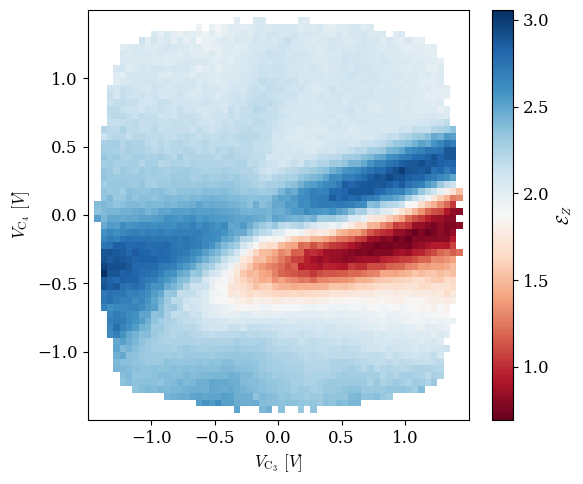

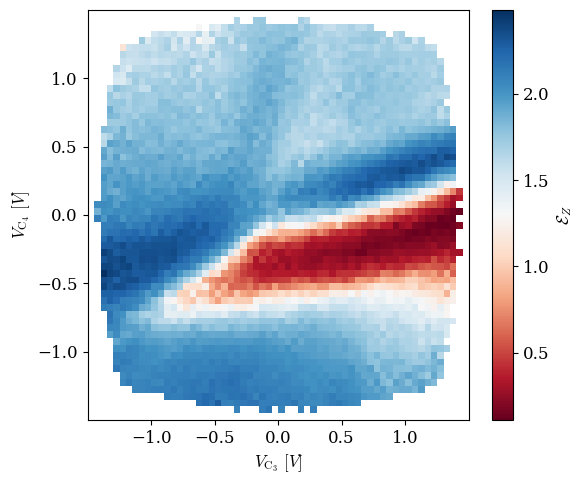

In [120]:
thetas_cpu = thetas.detach().cpu().numpy()
scores_cpu = scores.detach().cpu().numpy()
c_1 = 1
c_2 = 2
mean_grid, q_grid, count_grid, ei, ej = pairwise_heatmap_2d(thetas_cpu, scores_cpu, i=c_1, j=c_2, bins=60, min_cell_count=100, quantile=0.10)

fig_1 = plot_heatmap(mean_grid, ei, ej, None, rf'$V_{{\mathrm{{C_{{{c_1+2}}}}}}} \, \, [V]$', rf'$V_{{\mathrm{{C_{{{c_2+2}}}}}}} \, \, [V]$')
fig_1 = plot_heatmap(q_grid, ei, ej, None, rf'$V_{{\mathrm{{C_{{{c_1+2}}}}}}} \, \, [V]$', rf'$V_{{\mathrm{{C_{{{c_2+2}}}}}}} \, \, [V]$')

plt.show()

3.8660454750061035
Controls: tensor([0.8521, 0.6534, 1.0420, 1.0655, 0.7785, 0.1411])


FileNotFoundError: [Errno 2] No such file or directory: '/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/found_1d_functions/opt_type=random_func_type=linear_data_type=data_vMB_ring_1e7.npz'

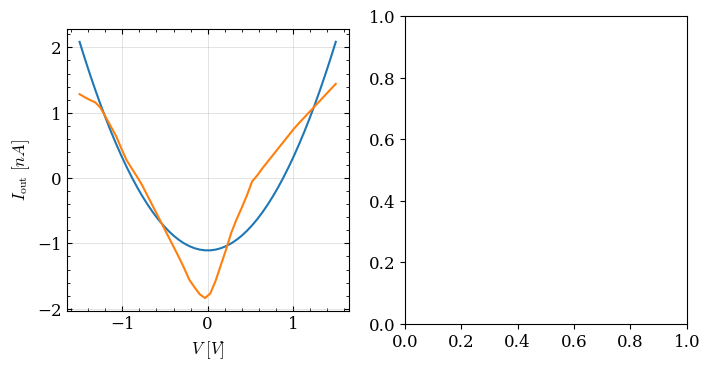

In [10]:
fig, ax = plt.subplots(ncols=2, figsize=(8,4))
n_points = 50

ax_1 = ax[0]
ax_2 = ax[1]

print(max_score)
controls = torch.tensor(thetas[min_index].tolist()).expand(n_points, -1)
print("Controls:", controls[0, :])

control_indices = [i for i in range(num_voltages) if i != input_index]
#print(control_indices)
input_range = torch.linspace(v_min, v_max, n_points).unsqueeze(0)

input_tensor = torch.zeros(n_points, num_voltages)
input_tensor[:, input_index] = input_range
for j, k in enumerate(control_indices):
    input_tensor[:, k] = controls[:, j]
input_tensor = input_tensor.to(device)
model.eval()
with torch.no_grad():
    y_out = model(input_tensor).detach().cpu().numpy().squeeze()

ax_1.plot(input_range.squeeze(), normalize_over_range(target_function(input_range).squeeze()))
ax_1.set_box_aspect(1)
ax_1.minorticks_on()
ax_1.tick_params(direction='in', which='both')
ax_1.tick_params(top=True, right=True, which='both')
ax_1.grid(lw=0.5, alpha=0.5)
ax_1.set_xlabel(r'$V \, \, [V]$')
ax_1.set_ylabel(r'$I_{\mathrm{out}} \, \, [nA]$')

ax_1.plot(input_range.squeeze(), normalize_over_range(y_out))

data = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/found_1d_functions/opt_type=random_func_type=linear_data_type=data_vMB_ring_1e7.npz')
print(data['control'])
I_controls = data['control']
I_out = data['current'] * time_scale
I_err = data['sem'] * time_scale
n_points = I_out.shape[0]
ax_2.plot(input_range.squeeze(), I_out)
ax_2.fill_between(input_range.squeeze(), I_out - 1.96*I_err, I_out + 1.96*I_err, alpha=0.3)
#ax_2.plot(input_range.squeeze(), y_out)
ax_2.set_box_aspect(1)
ax_2.minorticks_on()
ax_2.tick_params(direction='in', which='both')
ax_2.tick_params(top=True, right=True, which='both')
ax_2.grid(lw=0.5, alpha=0.5)
ax_2.tick_params(labelleft=False, labelright=True)
ax_2.set_ylabel(r'$I_{\mathrm{out}} \, \, [nA]$')
ax_2.set_xlabel(r'$V \, \, [V]$')
ax_2.yaxis.set_label_position('right')

## Show 5 best-scoring contol voltage vectors

In [11]:
m = 5
top_idx = sorted(range(len(scores)), key=scores.__getitem__, reverse=True)[:m]
top = [(i, scores[i]) for i in top_idx]

print(top_idx)  # e.g. [2, 4, 0]
print(top)      # e.g. [(2, 25), (4, 25), (0, 10)]

[87593, 95111, 54840, 8278, 95945]
[(87593, tensor(3.8660)), (95111, tensor(3.8490)), (54840, tensor(3.7721)), (8278, tensor(3.7209)), (95945, tensor(3.7091))]


Controls: tensor([-0.2712, -1.1891,  1.1944,  0.8894, -0.1246, -0.0143])
Controls: tensor([-0.2826, -1.2478,  1.2028, -0.2058,  0.9315,  0.0805])
Controls: tensor([-0.2700, -1.1394,  1.1342, -0.0346,  1.1565, -0.0620])
Controls: tensor([-0.2500, -1.2894,  0.6793,  0.6013,  0.7155,  0.9695])
Controls: tensor([-0.0638,  0.3659,  1.1656,  0.8318,  0.0939, -1.3426])


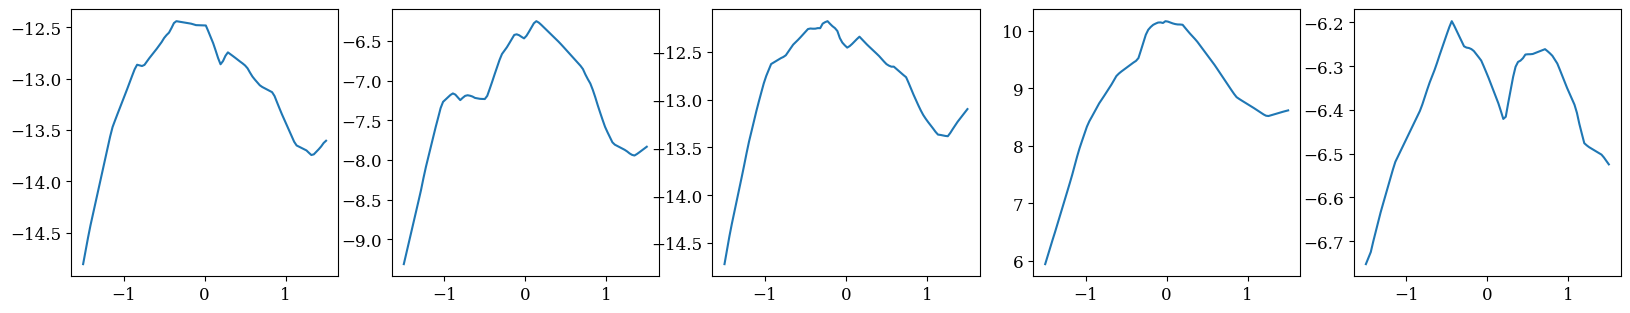

In [14]:
n_points = 100
plotting_range = np.linspace(v_min, v_max, n_points)

fig, ax = plt.subplots(ncols=m, figsize=(m*4, 4))

for a in ax:
    a.set_box_aspect(1)

for i, k in enumerate(top_idx):

    controls = torch.tensor(thetas[k].tolist()).expand(n_points, -1)
    print("Controls:", controls[0, :])
    
    control_indices = [i for i in range(num_voltages) if i != input_index]

    input_range = torch.linspace(v_min, v_max, n_points).unsqueeze(0)
    
    input_tensor = torch.zeros(n_points, num_voltages)
    input_tensor[:, input_index] = input_range
    for j, k in enumerate(control_indices):
        input_tensor[:, k] = controls[:, j]
    input_tensor = input_tensor.to(device)
    model.eval()
    with torch.no_grad():
        y_out = model(input_tensor).detach().cpu().numpy().squeeze()

    ax[i].plot(plotting_range, y_out)